# 09 · Hyperparameter Tuning

[← Course home](../README.md)

**What you will learn**

- The difference between **parameters** (learned by `fit`) and **hyperparameters** (chosen by you)
- **Validation curves**: the score as a function of one hyperparameter
- `GridSearchCV` with pipelines (`step__param` names) and a heat-map of a 2-D search over SVC's `C` × `gamma`
- `RandomizedSearchCV` with `scipy.stats` distributions (`loguniform`), and **why random search beats grid search**
  when only a few hyperparameters matter (Bergstra & Bengio, 2012)
- **Successive halving** (`HalvingRandomSearchCV`) to spend compute on promising candidates
- Search budget vs best score, `refit`, and analysing `cv_results_`
- How tuning **overfits the validation data**, and **nested cross-validation** to get an unbiased estimate
- Practical tips: log scales, coarse-to-fine, what to tune first

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.datasets import load_breast_cancer, load_digits, load_wine
from sklearn.experimental import enable_halving_search_cv  # noqa: F401  (activates the Halving* classes)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, HalvingRandomSearchCV, KFold, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score, train_test_split, validation_curve)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mlaz import PALETTE, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 60)

## 1 · Parameters vs hyperparameters

- **Parameters** are learned from data by `fit`: the coefficients $\mathbf w$ of a logistic regression, the split
  thresholds of a tree, the support vectors of an SVM. In scikit-learn they end with an underscore (`coef_`).
- **Hyperparameters** are set *before* fitting and control *how* the model learns: the regularisation strength
  `C`, the tree `max_depth`, the kernel width `gamma`. They are the constructor arguments (`get_params()`).

Hyperparameters cannot be learned by minimising the training loss (training error would always prefer the most
flexible model), so we choose them by estimated **generalisation** performance — i.e. with cross-validation.

In [2]:
cancer = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(cancer.data, cancer.target, test_size=0.25,
                                              stratify=cancer.target, random_state=RANDOM_STATE)
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000))
pipe_lr.fit(Xb_tr, yb_tr)
print("hyperparameters (a few):", {k: v for k, v in pipe_lr.get_params().items()
                                   if k in ("logisticregression__C", "logisticregression__max_iter",
                                            "standardscaler__with_mean")})
print("learned parameters     : coef_ shape", pipe_lr[-1].coef_.shape, "| first 3 coefs",
      pipe_lr[-1].coef_[0, :3].round(3), "| intercept_", pipe_lr[-1].intercept_.round(3))

hyperparameters (a few): {'standardscaler__with_mean': True, 'logisticregression__C': 1.0, 'logisticregression__max_iter': 2000}
learned parameters     : coef_ shape (1, 30) | first 3 coefs [-0.523 -0.519 -0.484] | intercept_ [0.281]


Note the naming: inside a `Pipeline` a hyperparameter is addressed as **`<step name>__<parameter>`**
(double underscore). `make_pipeline` names steps after their lower-cased class name. Nested objects chain further,
e.g. `columntransformer__num__imputer__strategy`.

## 2 · Validation curves

A **validation curve** plots training and CV score against one hyperparameter. We use an RBF-kernel SVM on the
handwritten **digits** (1 797 8×8 images, 10 classes). `gamma` is the inverse kernel width:
$K(\mathbf x, \mathbf x') = \exp(-\gamma\lVert \mathbf x - \mathbf x'\rVert^2)$.

validation_curve: 33 fits in 3.2s; best gamma = 1e-02, CV accuracy = 0.976


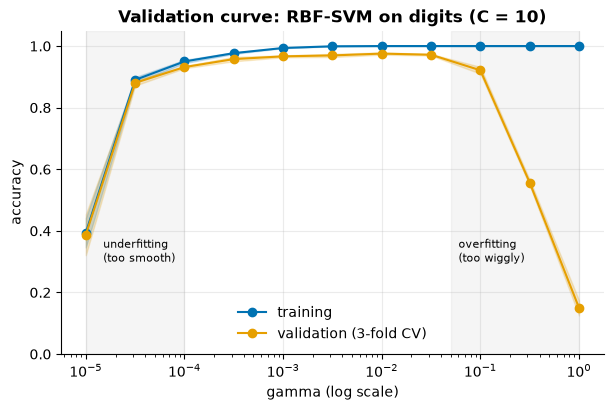

In [3]:
digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.25,
                                              stratify=digits.target, random_state=RANDOM_STATE)
svc_pipe = Pipeline([("scale", StandardScaler()), ("svc", SVC(C=10))])
gammas = np.logspace(-5, 0, 11)
cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time()
tr_sc, va_sc = validation_curve(svc_pipe, Xd_tr, yd_tr, param_name="svc__gamma", param_range=gammas,
                                cv=cv3, n_jobs=-1)
print(f"validation_curve: {len(gammas) * 3} fits in {time.time() - t0:.1f}s; "
      f"best gamma = {gammas[va_sc.mean(1).argmax()]:.0e}, CV accuracy = {va_sc.mean(1).max():.3f}")

fig, ax = plt.subplots()
for s, lab, c in [(tr_sc, "training", PALETTE[0]), (va_sc, "validation (3-fold CV)", PALETTE[1])]:
    ax.semilogx(gammas, s.mean(1), "o-", color=c, label=lab)
    ax.fill_between(gammas, s.mean(1) - s.std(1), s.mean(1) + s.std(1), color=c, alpha=0.2)
ax.axvspan(gammas[0], 1e-4, color="gray", alpha=0.08)
ax.axvspan(5e-2, gammas[-1], color="gray", alpha=0.08)
ax.text(1.5e-5, 0.3, "underfitting\n(too smooth)", fontsize=8)
ax.text(6e-2, 0.3, "overfitting\n(too wiggly)", fontsize=8)
ax.set(title="Validation curve: RBF-SVM on digits (C = 10)", xlabel="gamma (log scale)", ylabel="accuracy",
       ylim=(0, 1.05))
ax.legend(loc="lower center")
savefig("validation_curve")
plt.show()

Small `gamma` → very wide kernel → nearly linear, underfits. Large `gamma` → every training point is its own
island → 100 % training accuracy, validation accuracy collapses. Notice the **log scale**: useful values of
scale-type hyperparameters (`C`, `gamma`, `alpha`, `learning_rate`) span orders of magnitude.

## 3 · Grid search

`GridSearchCV` evaluates **every combination** of a parameter grid with cross-validation, then (by default)
**refits** the best combination on the whole training set:

```python
param_grid = {"svc__C": np.logspace(-2, 4, 13), "svc__gamma": np.logspace(-6, 0, 13)}
```

13 × 13 = 169 candidates × 3 folds = 507 fits. (A big grid, on purpose: we will reuse it as the "ground truth"
surface for comparing search strategies below.)

In [4]:
Cs = np.logspace(-2, 4, 13)
gammas_grid = np.logspace(-6, 0, 13)
grid = GridSearchCV(svc_pipe, {"svc__C": Cs, "svc__gamma": gammas_grid}, cv=cv3, n_jobs=-1,
                    return_train_score=True)
t0 = time.time()
grid.fit(Xd_tr, yd_tr)
grid_time = time.time() - t0
print(f"GridSearchCV: {len(grid.cv_results_['params'])} candidates x 3 folds in {grid_time:.1f}s")
print("best params :", {k: f"{v:.3g}" for k, v in grid.best_params_.items()})
print(f"best CV acc : {grid.best_score_:.4f}")
print(f"test acc of refitted best_estimator_: {grid.score(Xd_te, yd_te):.4f}")

GridSearchCV: 169 candidates x 3 folds in 17.8s
best params : {'svc__C': '31.6', 'svc__gamma': '0.01'}
best CV acc : 0.9762
test acc of refitted best_estimator_: 0.9822


`cv_results_` is a dict of arrays — easiest to read as a DataFrame. Useful columns: `params`, `mean_test_score`,
`std_test_score`, `rank_test_score`, `mean_fit_time`, and `mean_train_score` (if `return_train_score=True`).

In [5]:
res = pd.DataFrame(grid.cv_results_)
cols = ["param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score", "mean_train_score",
        "mean_fit_time", "rank_test_score"]
res.sort_values("rank_test_score")[cols].head(8)

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,mean_train_score,mean_fit_time,rank_test_score
125,316.2278,0.01,0.9762,0.0046,1.0000,0.0261,1
99,31.6228,0.01,0.9762,0.0046,1.0000,0.0241,1
112,100.0000,0.01,0.9762,0.0046,1.0000,0.0211,1
138,1000.0000,0.01,0.9762,0.0046,1.0000,0.0206,1
151,3162.2777,0.01,0.9762,0.0046,1.0000,0.0341,1
164,10000.0000,0.01,0.9762,0.0046,1.0000,0.0366,1
86,10.0000,0.01,0.9755,0.0036,1.0000,0.0276,7
73,3.1623,0.01,0.9733,0.0048,0.9993,0.0230,8


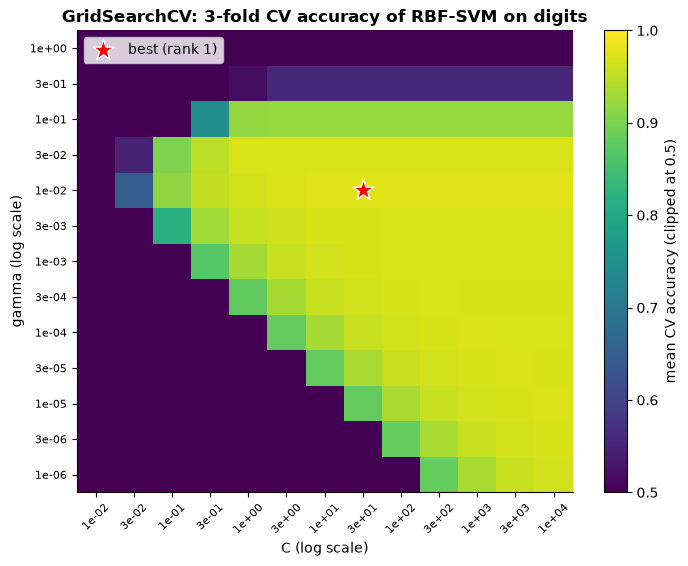

In [6]:
scores = res.pivot(index="param_svc__gamma", columns="param_svc__C", values="mean_test_score")
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(scores.values, origin="lower", cmap="viridis", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(Cs)), [f"{c:.0e}" for c in Cs], rotation=45, fontsize=8)
ax.set_yticks(range(len(gammas_grid)), [f"{g:.0e}" for g in gammas_grid], fontsize=8)
bi = (np.argmin(abs(gammas_grid - grid.best_params_["svc__gamma"])),
      np.argmin(abs(Cs - grid.best_params_["svc__C"])))
ax.scatter(bi[1], bi[0], marker="*", s=250, color="red", edgecolor="white", label="best (rank 1)")
ax.set(title="GridSearchCV: 3-fold CV accuracy of RBF-SVM on digits", xlabel="C (log scale)",
       ylabel="gamma (log scale)")
ax.grid(False)
ax.legend(loc="upper left", frameon=True)
cb = fig.colorbar(im, ax=ax)
cb.set_label("mean CV accuracy (clipped at 0.5)")
savefig("grid_heatmap")
plt.show()

The heat-map shows the classic SVM picture: a **diagonal ridge** of good models — larger `C` (weaker
regularisation) can be compensated by a smaller `gamma` (smoother kernel) — with underfitting at the bottom-left
and overfitting at the top. Two lessons:

1. **Always plot the search result.** If the best value is on the edge of the grid, extend the grid.
2. The good region is broad: many combinations are within noise of the best one (see §7).

## 4 · Random search, and why it beats grid search

`RandomizedSearchCV` samples `n_iter` candidates from **distributions**. For scale parameters use
`scipy.stats.loguniform(a, b)`: uniform in $\log$ space, so each decade gets the same probability.

In [7]:
dist = loguniform(1e-6, 1e0)
sample = dist.rvs(size=10000, random_state=RANDOM_STATE)
print("share of loguniform(1e-6, 1) samples per decade:",
      np.histogram(np.log10(sample), bins=np.arange(-6, 1))[0] / len(sample))

share of loguniform(1e-6, 1) samples per decade: [0.1703 0.1672 0.1701 0.1691 0.1637 0.1596]


**Bergstra & Bengio (2012)'s argument.** Usually only a few hyperparameters really matter
("low effective dimensionality"), and we do not know which in advance. With a 3 × 3 grid over one *important* and
one *unimportant* parameter, 9 trials test only **3 distinct values** of the important one. 9 random trials test
**9 distinct values**.

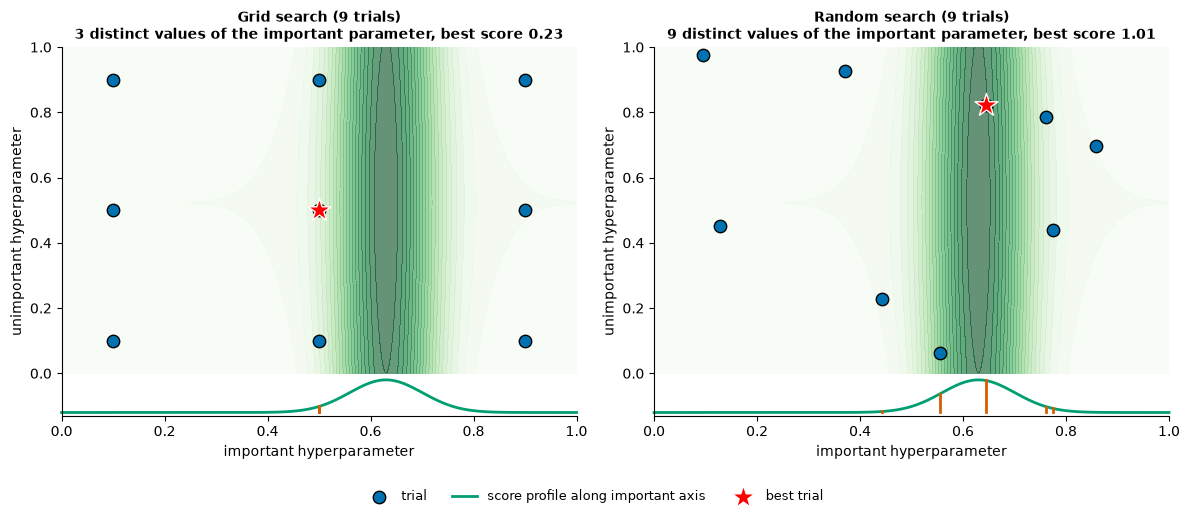

In [8]:
def f_important(x):  # performance depends (mostly) on x only
    return np.exp(-((x - 0.63) ** 2) / 0.01)


def g_unimportant(y):
    return 0.05 * np.sin(3 * y)


gx = np.linspace(0.1, 0.9, 3)
grid_pts = np.array([(x, y) for x in gx for y in gx])
rand_pts = rng.uniform(0, 1, size=(9, 2))
xs = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pts, name in [(axes[0], grid_pts, "Grid search (9 trials)"), (axes[1], rand_pts, "Random search (9 trials)")]:
    X_, Y_ = np.meshgrid(xs, xs)
    ax.contourf(X_, Y_, f_important(X_) + g_unimportant(Y_), levels=20, cmap="Greens", alpha=0.6)
    ax.scatter(pts[:, 0], pts[:, 1], s=80, color=PALETTE[0], edgecolor="k", zorder=3, label="trial")
    ax.plot(xs, -0.12 + 0.1 * f_important(xs), color=PALETTE[2], lw=2, clip_on=False,
            label="score profile along important axis")
    for x in pts[:, 0]:
        ax.plot([x, x], [-0.12, -0.12 + 0.1 * f_important(x)], color=PALETTE[3], lw=2, clip_on=False)
    best = pts[np.argmax(f_important(pts[:, 0]) + g_unimportant(pts[:, 1]))]
    ax.scatter(*best, marker="*", s=300, color="red", edgecolor="white", zorder=4, label="best trial")
    ax.set(title=f"{name}\n{len(np.unique(pts[:, 0].round(6)))} distinct values of the important parameter, "
                 f"best score {f_important(best[0]) + g_unimportant(best[1]):.2f}",
           xlabel="important hyperparameter", ylabel="unimportant hyperparameter", xlim=(0, 1), ylim=(-0.13, 1))
    ax.title.set_fontsize(10)
    ax.grid(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.04, 1, 1))
savefig("random_vs_grid_illustration")
plt.show()

Now on the real SVM problem. Because we evaluated the full 13 × 13 grid, we can **simulate** many searches cheaply:

- a **grid** search with budget $k^2$ uses $k$ evenly spaced values of each parameter (a subset of the big grid);
- a **random** search with budget $n$ samples $n$ points from the 169 lattice points (≈ loguniform sampling).

For each budget we report the true (3-fold CV) accuracy of the best configuration found, averaged over 200 random
searches. To mimic "one important, one unimportant parameter", we also make a variant of the surface where we add
a third, *irrelevant* hyperparameter: a 3-D grid then wastes a factor $k$ of its budget.

In [9]:
S = scores.values  # 13 x 13 CV accuracy surface (gamma x C)
budgets = [4, 9, 16, 25, 36, 49, 64, 100, 169]
n_rep = 200


def grid_best(k):
    idx = np.unique(np.round(np.linspace(0, 12, k)).astype(int))
    return S[np.ix_(idx, idx)].max()


def grid3d_best(budget):  # k x k x k grid with an irrelevant 3rd parameter: only k^2 useful (C, gamma) pairs
    k = max(1, int(round(budget ** (1 / 3))))
    return grid_best(k)


rows = []
for b in budgets:
    rand = [S.ravel()[rng.choice(S.size, size=b, replace=False)].max() for _ in range(n_rep)]
    rows.append(dict(budget=b, grid_2d=grid_best(int(round(np.sqrt(b)))), grid_3d_irrelevant=grid3d_best(b),
                     random_mean=np.mean(rand), random_p10=np.percentile(rand, 10),
                     random_p90=np.percentile(rand, 90)))
budget_df = pd.DataFrame(rows).set_index("budget")
budget_df

,grid_2d,grid_3d_irrelevant,random_mean,random_p10,random_p90
budget,,,,,
4,0.9651,0.9651,0.9454,0.9213,0.9762
9,0.9725,0.9651,0.9721,0.9703,0.9762
16,0.9762,0.9725,0.9744,0.9718,0.9762
25,0.9725,0.9725,0.9751,0.9725,0.9762
36,0.9733,0.9725,0.9755,0.9733,0.9762
49,0.9762,0.9762,0.9758,0.9733,0.9762
64,0.9733,0.9762,0.9762,0.9762,0.9762
100,0.9762,0.9725,0.9762,0.9762,0.9762
169,0.9762,0.9733,0.9762,0.9762,0.9762


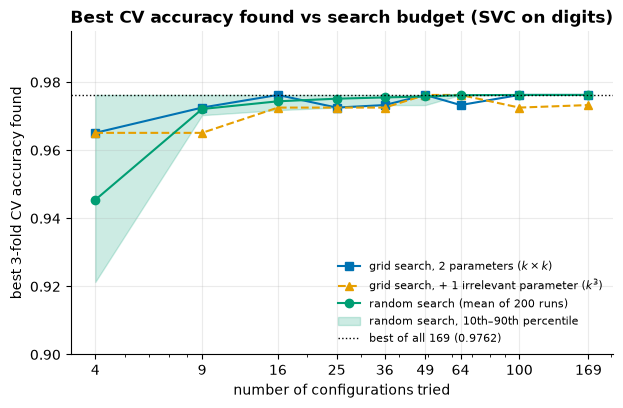

In [10]:
fig, ax = plt.subplots()
ax.plot(budget_df.index, budget_df.grid_2d, "s-", label="grid search, 2 parameters ($k\\times k$)")
ax.plot(budget_df.index, budget_df.grid_3d_irrelevant, "^--",
        label="grid search, + 1 irrelevant parameter ($k^3$)")
ax.plot(budget_df.index, budget_df.random_mean, "o-", label="random search (mean of 200 runs)")
ax.fill_between(budget_df.index, budget_df.random_p10, budget_df.random_p90, alpha=0.2, color=PALETTE[2],
                label="random search, 10th–90th percentile")
ax.axhline(S.max(), color="k", ls=":", lw=1, label=f"best of all 169 ({S.max():.4f})")
ax.set_xscale("log")
ax.set(title="Best CV accuracy found vs search budget (SVC on digits)", xlabel="number of configurations tried",
       ylabel="best 3-fold CV accuracy found", ylim=(0.9, 0.995))
ax.set_xticks(budgets, [str(b) for b in budgets])
ax.legend(fontsize=8, loc="lower right")
savefig("search_budget")
plt.show()

With a couple of dozen trials, random search gets within a fraction of a percent of the best of all 169
configurations. Grid search is competitive in 2-D when the grid happens to hit the ridge, but its budget grows
as $k^d$, and every irrelevant parameter multiplies the cost without improving the result. Random search's
budget is independent of the number of parameters, you can stop it any time, and adding a useless parameter
costs nothing.

Here is a real `RandomizedSearchCV` with continuous distributions and 25 candidates:

In [11]:
rand_search = RandomizedSearchCV(svc_pipe, {"svc__C": loguniform(1e-2, 1e4), "svc__gamma": loguniform(1e-6, 1e0)},
                                 n_iter=25, cv=cv3, n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time()
rand_search.fit(Xd_tr, yd_tr)
rand_time = time.time() - t0
print(f"RandomizedSearchCV: 25 candidates in {rand_time:.1f}s")
print("best params:", {k: f"{v:.3g}" for k, v in rand_search.best_params_.items()},
      f"| best CV acc {rand_search.best_score_:.4f} | test acc {rand_search.score(Xd_te, yd_te):.4f}")

RandomizedSearchCV: 25 candidates in 2.1s
best params: {'svc__C': '40.4', 'svc__gamma': '0.0177'} | best CV acc 0.9733 | test acc 0.9800


## 5 · Successive halving

Most candidates are obviously bad after a cheap look. **Successive halving** (Jamieson & Talwalkar 2016; the core
of Hyperband) starts **many candidates with a small resource** (here: few training samples), keeps the best
$1/\eta$ fraction, multiplies the resource by $\eta$, and repeats:

$$\text{iteration } i:\quad n_i = \Big\lceil\frac{n_0}{\eta^{\,i}}\Big\rceil \text{ candidates},\qquad
  r_i = r_0\,\eta^{\,i} \text{ samples each}.$$

In scikit-learn it is still experimental and must be enabled with
`from sklearn.experimental import enable_halving_search_cv`.

In [12]:
halving = HalvingRandomSearchCV(svc_pipe, {"svc__C": loguniform(1e-2, 1e4), "svc__gamma": loguniform(1e-6, 1e0)},
                                n_candidates=100, factor=3, resource="n_samples", min_resources=40, cv=cv3,
                                n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time()
halving.fit(Xd_tr, yd_tr)
halving_time = time.time() - t0
print(f"HalvingRandomSearchCV: {halving.n_iterations_} iterations, candidates {halving.n_candidates_}, "
      f"resources {halving.n_resources_} in {halving_time:.1f}s")
print("best params:", {k: f"{v:.3g}" for k, v in halving.best_params_.items()},
      f"| best CV acc {halving.best_score_:.4f} | test acc {halving.score(Xd_te, yd_te):.4f}")

HalvingRandomSearchCV: 4 iterations, candidates [100, 34, 12, 4], resources [40, 120, 360, 1080] in 1.9s
best params: {'svc__C': '2.53e+03', 'svc__gamma': '0.00629'} | best CV acc 0.9741 | test acc 0.9822


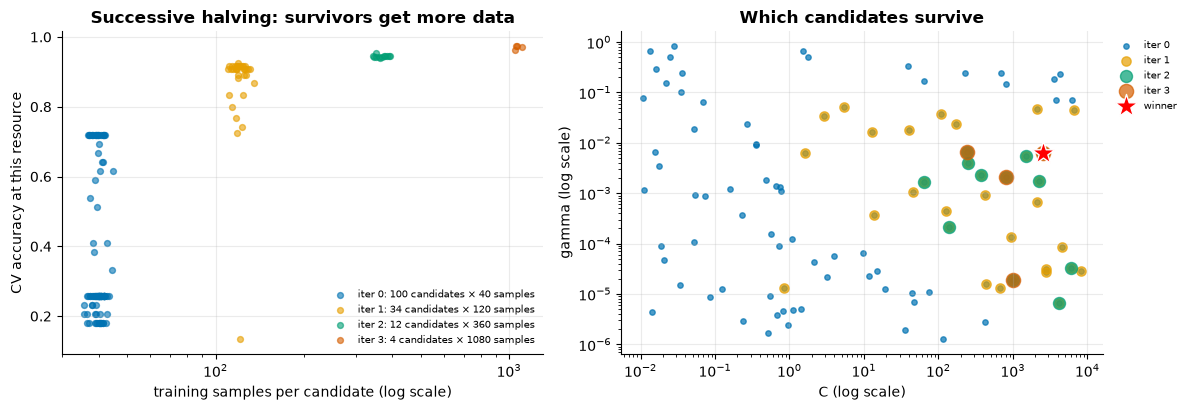

In [13]:
hres = pd.DataFrame(halving.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
for it in range(halving.n_iterations_):
    sub = hres[hres.iter == it]
    ax.scatter(np.full(len(sub), halving.n_resources_[it]) * np.exp(rng.normal(0, 0.05, len(sub))),
               sub.mean_test_score, s=18, alpha=0.6, color=PALETTE[it % len(PALETTE)],
               label=f"iter {it}: {len(sub)} candidates × {halving.n_resources_[it]} samples")
ax.set_xscale("log")
ax.set(title="Successive halving: survivors get more data", xlabel="training samples per candidate (log scale)",
       ylabel="CV accuracy at this resource")
ax.legend(fontsize=7, loc="lower right")
ax = axes[1]
for it in range(halving.n_iterations_):
    sub = hres[hres.iter == it]
    ax.scatter(sub.param_svc__C.astype(float), sub.param_svc__gamma.astype(float), s=15 + 30 * it,
               color=PALETTE[it % len(PALETTE)], alpha=0.7, label=f"iter {it}")
ax.scatter(halving.best_params_["svc__C"], halving.best_params_["svc__gamma"], marker="*", s=300, color="red",
           edgecolor="white", label="winner", zorder=5)
ax.set(xscale="log", yscale="log", title="Which candidates survive", xlabel="C (log scale)",
       ylabel="gamma (log scale)")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
savefig("successive_halving")
plt.show()

### Budget comparison

The three searches side by side (all 3-fold CV on the same 1 347 training digits; times depend on your machine):

In [14]:
def n_fits(search):
    return len(search.cv_results_["params"]) * 3


# equivalent "full-data fits": halving fits on small subsets are cheaper, weigh them by the sample fraction
halving_equiv = (hres.n_resources / len(Xd_tr)).sum() * 3
comparison = pd.DataFrame({
    "GridSearchCV (13x13)": dict(candidates=len(grid.cv_results_["params"]), cv_fits=n_fits(grid),
                                 full_data_fit_equivalents=n_fits(grid), time_s=grid_time,
                                 best_cv=grid.best_score_, test=grid.score(Xd_te, yd_te)),
    "RandomizedSearchCV (25)": dict(candidates=25, cv_fits=n_fits(rand_search),
                                    full_data_fit_equivalents=n_fits(rand_search), time_s=rand_time,
                                    best_cv=rand_search.best_score_, test=rand_search.score(Xd_te, yd_te)),
    "HalvingRandomSearchCV (100)": dict(candidates=100, cv_fits=n_fits(halving),
                                        full_data_fit_equivalents=halving_equiv, time_s=halving_time,
                                        best_cv=halving.best_score_, test=halving.score(Xd_te, yd_te)),
}).T
comparison.round(4)

,candidates,cv_fits,full_data_fit_equivalents,time_s,best_cv,test
GridSearchCV (13x13),169.0,507.0,507.0000,17.7905,0.9762,0.9822
RandomizedSearchCV (25),25.0,75.0,75.0000,2.0610,0.9733,0.9800
HalvingRandomSearchCV (100),100.0,450.0,37.2383,1.8850,0.9741,0.9822


All three land at essentially the same test accuracy. Random search used ~15 % of the grid's fits; halving
screened 100 candidates for the cost of
about 37 full-data fits (its 450 fits were mostly on small subsets). (Halving's `best_score_` is computed on the
final iteration's resource, so it is not strictly comparable.)

## 6 · `refit`, and choosing a simpler model: the one-standard-error rule

After the search, `refit=True` retrains the winner on the full training set (`best_estimator_`), so the search
object can `predict` directly. `refit` may also be a **callable** that receives `cv_results_` and returns the
index of the model to refit. A classic choice is the **one-standard-error rule**: among all candidates whose score
is within one standard error of the best, take the *simplest* (most regularised) one.

We use it on logistic regression for breast cancer, where "simpler" = smaller `C`.

In [15]:
def one_standard_error(cv_results):
    r = pd.DataFrame(cv_results)
    best = r.mean_test_score.idxmax()
    n_splits = sum(c.startswith("split") and c.endswith("_test_score") for c in r.columns)
    threshold = r.mean_test_score[best] - r.std_test_score[best] / np.sqrt(n_splits)
    ok = r[r.mean_test_score >= threshold]
    return int(ok.param_logisticregression__C.astype(float).idxmin())  # smallest C = strongest regularisation


C_grid = {"logisticregression__C": np.logspace(-3, 2, 21)}
cv10 = StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE)
gs_best = GridSearchCV(pipe_lr, C_grid, cv=cv10, n_jobs=-1).fit(Xb_tr, yb_tr)
gs_1se = GridSearchCV(pipe_lr, C_grid, cv=cv10, n_jobs=-1, refit=one_standard_error).fit(Xb_tr, yb_tr)
r = pd.DataFrame(gs_best.cv_results_)
print(f"argmax rule : C = {gs_best.best_params_['logisticregression__C']:.4f}, "
      f"CV acc {r.mean_test_score.max():.4f}, test acc {gs_best.score(Xb_te, yb_te):.4f}")
i1 = gs_1se.best_index_
print(f"1-SE rule   : C = {gs_1se.cv_results_['params'][i1]['logisticregression__C']:.4f}, "
      f"CV acc {gs_1se.cv_results_['mean_test_score'][i1]:.4f}, test acc {gs_1se.score(Xb_te, yb_te):.4f}")

argmax rule : C = 0.1778, CV acc 0.9790, test acc 0.9860
1-SE rule   : C = 0.0562, CV acc 0.9766, test acc 0.9650


The 1-SE rule picks a 3× more strongly regularised model whose CV accuracy is only 0.2 points lower. On *this*
test set it happens to do worse (0.965 vs 0.986 — a difference of 3 of the 143 tumours, well within noise).
The rule is a heuristic: it deliberately trades a sliver of estimated accuracy for a simpler, more stable model,
and it will not always win on a particular test set. Use it when many candidates are statistically tied and
simplicity (fewer features, smoother functions, cheaper inference) has value in itself.

(With a callable `refit`, `best_score_` is not defined; read the score from `cv_results_` at `best_index_`.)

## 7 · Tuning overfits the validation data

The best CV score of a search is the **maximum** of many noisy estimates, so it is **optimistically biased**:
the more configurations you try, the more likely one looks good by luck. Extreme demo: labels are **pure coin
flips**, 150 training samples, 20 noise features. We try up to 200 random "configurations" of a k-NN classifier
(random `n_neighbors` and a random feature subset) and keep the best by 5-fold CV.

after 200 configurations: best CV accuracy = 0.627, accuracy of that model on 2000 fresh samples = 0.511


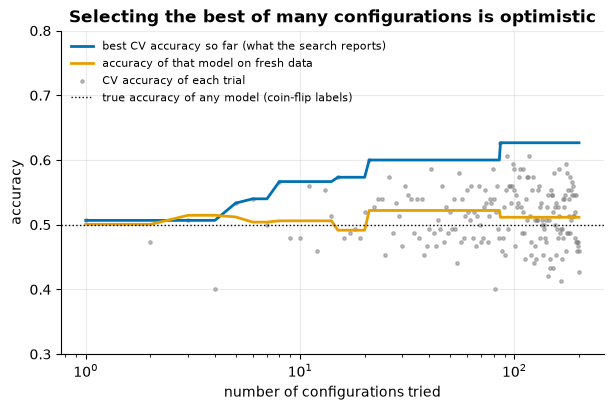

In [16]:
n, p = 150, 20
X_noise = rng.normal(size=(n + 2000, p))
y_noise = rng.integers(0, 2, n + 2000)
Xn_tr, yn_tr, Xn_te, yn_te = X_noise[:n], y_noise[:n], X_noise[n:], y_noise[n:]
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

trials = []
for t in range(200):
    k = int(rng.integers(1, 31))
    feats = rng.choice(p, size=int(rng.integers(1, p + 1)), replace=False)
    model = KNeighborsClassifier(n_neighbors=k)
    cv_acc = cross_val_score(model, Xn_tr[:, feats], yn_tr, cv=cv5).mean()
    trials.append((k, feats, cv_acc))

best_cv, test_of_best = [], []
cur = -1
for i, (k, feats, cv_acc) in enumerate(trials):
    if cv_acc > cur:
        cur, cur_model = cv_acc, (k, feats)
        m = KNeighborsClassifier(n_neighbors=k).fit(Xn_tr[:, feats], yn_tr)
        cur_test = m.score(Xn_te[:, feats], yn_te)
    best_cv.append(cur)
    test_of_best.append(cur_test)
print(f"after 200 configurations: best CV accuracy = {best_cv[-1]:.3f}, "
      f"accuracy of that model on 2000 fresh samples = {test_of_best[-1]:.3f}")

fig, ax = plt.subplots()
ax.plot(np.arange(1, 201), best_cv, label="best CV accuracy so far (what the search reports)", lw=2)
ax.plot(np.arange(1, 201), test_of_best, label="accuracy of that model on fresh data", lw=2)
ax.scatter(np.arange(1, 201), [t[2] for t in trials], s=6, color="gray", alpha=0.5, label="CV accuracy of each trial")
ax.axhline(0.5, color="k", ls=":", lw=1, label="true accuracy of any model (coin-flip labels)")
ax.set_xscale("log")
ax.set(title="Selecting the best of many configurations is optimistic", xlabel="number of configurations tried",
       ylabel="accuracy", ylim=(0.3, 0.8))
ax.legend(fontsize=8, loc="upper left")
savefig("optimistic_bias")
plt.show()

Nothing can be learned, yet the search reports a CV accuracy well above 50 % — the winner was simply the luckiest.
On real data the effect is smaller but always there, which is why the score that *selected* a model must never be
reported as its expected performance. You need data that played **no role in the selection**: a held-out test
set, or nested cross-validation.

## 8 · Nested cross-validation

```mermaid
flowchart TD
  D[Full dataset] --> O{Outer CV: k folds}
  O -->|outer training part| I[Inner CV: GridSearchCV picks hyperparameters]
  I --> R[Refit best config on outer training part]
  R --> E[Score on outer test fold, never seen by the search]
  E --> A[Average outer scores = estimate of the whole tuning procedure]
```

The **inner** loop chooses hyperparameters; the **outer** loop evaluates the *entire procedure*
("grid-search an SVC"), so the outer score is an (almost) unbiased estimate of how well that procedure will do on
new data. First, the explicit loop on the wine data (178 wines, 3 cultivars, 13 chemical features):

In [17]:
wine = load_wine()
Xw, yw = wine.data, wine.target
p_grid = {"svc__C": np.logspace(-2, 3, 6), "svc__gamma": np.logspace(-4, 1, 6)}
svc_wine = Pipeline([("scale", StandardScaler()), ("svc", SVC())])

outer = KFold(5, shuffle=True, random_state=RANDOM_STATE)
inner = KFold(4, shuffle=True, random_state=RANDOM_STATE)
rows = []
for fold, (tr, te) in enumerate(outer.split(Xw)):
    search = GridSearchCV(svc_wine, p_grid, cv=inner).fit(Xw[tr], yw[tr])  # inner loop only sees tr
    rows.append(dict(outer_fold=fold, inner_best_score=search.best_score_,
                     C=search.best_params_["svc__C"], gamma=search.best_params_["svc__gamma"],
                     outer_test_score=search.score(Xw[te], yw[te])))
explicit = pd.DataFrame(rows)
print(f"nested CV estimate (explicit loop): {explicit.outer_test_score.mean():.4f} "
      f"± {explicit.outer_test_score.std():.4f}")
explicit

nested CV estimate (explicit loop): 0.9775 ± 0.0126


,outer_fold,inner_best_score,C,gamma,outer_test_score
0,0,0.9790,1.0,0.01,1.0000
1,1,0.9859,10.0,0.10,0.9722
2,2,0.9861,1.0,0.01,0.9722
3,3,0.9931,10.0,0.10,0.9714
4,4,0.9861,10.0,0.10,0.9714


Note that different outer folds may pick **different** hyperparameters — nested CV evaluates the *procedure*, not
one particular configuration. The same thing in one line: pass the search object as the estimator to
`cross_val_score`.

In [18]:
nested_one_liner = cross_val_score(GridSearchCV(svc_wine, p_grid, cv=inner), Xw, yw, cv=outer)
print("cross_val_score(GridSearchCV) :", nested_one_liner.round(4), "mean", nested_one_liner.mean().round(4))
print("identical to explicit loop    :", np.allclose(nested_one_liner, explicit.outer_test_score))

cross_val_score(GridSearchCV) : [1.     0.9722 0.9722 0.9714 0.9714] mean 0.9775
identical to explicit loop    : True


### Nested vs non-nested over repeated trials

Following scikit-learn's classic example, we repeat both estimates with 20 different random fold assignments:
the **non-nested** score is the `best_score_` of a single grid search over all data (the number people often
report); the **nested** score comes from the outer loop.

In [19]:
NUM_TRIALS = 20
non_nested, nested = np.zeros(NUM_TRIALS), np.zeros(NUM_TRIALS)
t0 = time.time()
for i in range(NUM_TRIALS):
    inner_cv = KFold(4, shuffle=True, random_state=i)
    outer_cv = KFold(4, shuffle=True, random_state=i)
    clf = GridSearchCV(svc_wine, p_grid, cv=inner_cv, n_jobs=-1)
    clf.fit(Xw, yw)
    non_nested[i] = clf.best_score_
    nested[i] = cross_val_score(clf, Xw, yw, cv=outer_cv).mean()
diff = non_nested - nested
print(f"{NUM_TRIALS} trials in {time.time() - t0:.1f}s")
print(f"non-nested mean {non_nested.mean():.4f}, nested mean {nested.mean():.4f}")
print(f"average optimistic bias = {diff.mean():.4f} (std {diff.std():.4f}); non-nested higher in "
      f"{np.mean(diff > 0):.0%} of trials")

20 trials in 42.2s
non-nested mean 0.9860, nested mean 0.9775
average optimistic bias = 0.0085 (std 0.0085); non-nested higher in 65% of trials


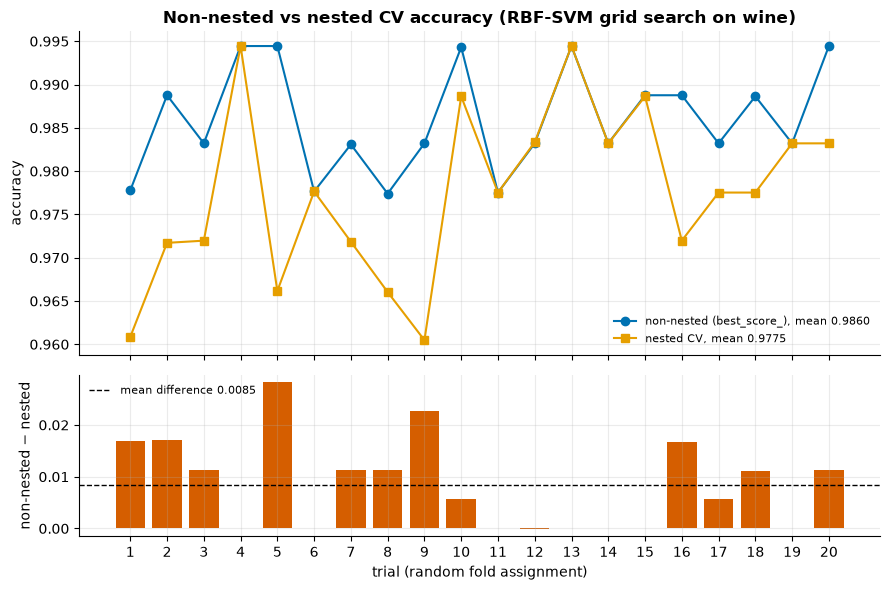

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
x = np.arange(1, NUM_TRIALS + 1)
axes[0].plot(x, non_nested, "o-", label=f"non-nested (best_score_), mean {non_nested.mean():.4f}")
axes[0].plot(x, nested, "s-", label=f"nested CV, mean {nested.mean():.4f}")
axes[0].set(title="Non-nested vs nested CV accuracy (RBF-SVM grid search on wine)", ylabel="accuracy")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].bar(x, diff, color=PALETTE[3])
axes[1].axhline(diff.mean(), color="k", ls="--", lw=1, label=f"mean difference {diff.mean():.4f}")
axes[1].set(xlabel="trial (random fold assignment)", ylabel="non-nested − nested", xticks=x)
axes[1].legend(fontsize=8, loc="upper left")
fig.tight_layout()
savefig("nested_vs_nonnested")
plt.show()

On an easy dataset like wine the bias is small in absolute terms (the models are near 98 %), but it is systematic:
the non-nested score is higher in most trials. With smaller datasets, bigger search spaces, or noisier targets it
grows — the noise demo in §7 is the extreme case.

> **Which model do I deploy?** Nested CV *estimates* performance; it does not produce a single model. After nested
> CV, run the search once more on all the data (`clf.fit(X, y)`) and deploy `clf.best_estimator_` — the nested
> score is your honest estimate of how that procedure performs.

## 9 · Practical tips

**Coarse-to-fine** on a log scale: first a wide, sparse search, then a finer one around the best region.

In [21]:
coarse = GridSearchCV(svc_pipe, {"svc__C": np.logspace(-2, 4, 4), "svc__gamma": np.logspace(-6, 0, 4)},
                      cv=cv3, n_jobs=-1).fit(Xd_tr, yd_tr)
c0, g0 = coarse.best_params_["svc__C"], coarse.best_params_["svc__gamma"]
fine = GridSearchCV(svc_pipe, {"svc__C": c0 * np.logspace(-1, 1, 5), "svc__gamma": g0 * np.logspace(-1, 1, 5)},
                    cv=cv3, n_jobs=-1).fit(Xd_tr, yd_tr)
print(f"coarse (16 candidates): C={c0:.3g}, gamma={g0:.3g}, CV acc {coarse.best_score_:.4f}")
print(f"fine   (25 candidates): C={fine.best_params_['svc__C']:.3g}, gamma={fine.best_params_['svc__gamma']:.3g}, "
      f"CV acc {fine.best_score_:.4f}, test acc {fine.score(Xd_te, yd_te):.4f}")
print(f"(full 169-candidate grid: CV acc {grid.best_score_:.4f})")

coarse (16 candidates): C=100, gamma=0.01, CV acc 0.9762
fine   (25 candidates): C=31.6, gamma=0.01, CV acc 0.9762, test acc 0.9822
(full 169-candidate grid: CV acc 0.9762)


Other tips:

| Tip | Why |
|---|---|
| Search scale parameters (`C`, `alpha`, `gamma`, `learning_rate`) on a **log scale** (`np.logspace`, `loguniform`) | effects are multiplicative |
| Tune the few parameters that matter first (SVM: `C`, `gamma`; GBM: `learning_rate`, `max_leaf_nodes`/`max_depth`, `min_samples_leaf`; RF: `max_features`, `min_samples_leaf`) | low effective dimensionality |
| Don't "tune" parameters that only trade compute for accuracy (`n_estimators` of a RF) — set them large enough; use early stopping for boosting | no overfitting risk / automatic |
| Put **all** preprocessing in the pipeline and tune it too (e.g. `columntransformer__num__imputer__strategy`) | prevents leakage, treats preprocessing as a hyperparameter |
| Prefer `RandomizedSearchCV` / halving for > 2 parameters; use grid for 1–2 parameters when you want a picture | budget independent of dimension |
| Consider the one-standard-error rule when many candidates tie | prefer the simpler of statistically tied models |
| Report the test (or nested CV) score, never `best_score_` | optimistic bias |
| Beyond this course: Bayesian optimisation (Optuna, scikit-optimize), Hyperband | model the score surface to choose the next trial |

## Key takeaways

- Hyperparameters are chosen by estimated generalisation performance (CV), not by training loss.
- Address pipeline hyperparameters as `step__param`; tune preprocessing and model together inside the pipeline.
- Plot validation curves and search heat-maps; search scale parameters on log scales; extend the grid if the
  optimum sits on its edge.
- Random search beats grid search for the same budget when only a few hyperparameters matter; successive halving
  screens many candidates cheaply.
- `best_score_` is optimistically biased (the maximum of noisy estimates). Use a held-out test set or **nested CV**
  to estimate the performance of the tuning procedure.

## Exercises

1. **Validation curve for C.** Draw the validation curve of `svc__C` at `gamma=1e-3` on digits. Where does it
   underfit/overfit? *Hint:* `validation_curve(..., param_name="svc__C", param_range=np.logspace(-3, 4, 15))`.
2. **Tune a gradient-boosting model** on breast cancer with `RandomizedSearchCV` over `learning_rate`
   (loguniform 0.01–1), `max_leaf_nodes` (randint 4–64) and `min_samples_leaf` (randint 5–50), 30 candidates.
   Which parameter matters most? *Hint:* plot `mean_test_score` against each parameter from `cv_results_`.
3. **Irrelevant parameters.** Add a useless parameter to the random search (e.g. `svc__tol` from
   `loguniform(1e-5, 1e-2)`) and confirm the best score is unchanged. What happens to a grid search if you add
   4 values of it? *Hint:* count the fits.
4. **Optimistic bias vs sample size.** Repeat the noise experiment in §7 with `n = 50, 150, 500, 2000`. How does the
   reported best CV accuracy change? *Hint:* the standard error of a CV accuracy is roughly $\sqrt{0.25/n}$.
5. **Nested CV for a pipeline with preprocessing.** Run nested CV on the digits data with a pipeline
   `StandardScaler → PCA → SVC`, tuning `pca__n_components` and `svc__C`. *Hint:* keep the grid small
   (e.g. 3 × 3) and use 3 inner / 3 outer folds to stay fast.